# ...

# Workflow Database

In [ ]:
from cosim import Flow
import cosim.db as db

* List available workflows

In [ ]:
db.ListFlows()

* Get all available workflows as dict

In [ ]:
Flows = db.GetFlows(Creator=None) #<--- set Creator=None to get dict object
Flows

In [ ]:
Flows = db.GetFlows(Creator=Flow) #<--- set Creator=Flow to get Flow object (nx.Digraph)
Flows

* View all available workflows

In [ ]:
for i,(name, flow) in enumerate(Flows.items()):
    print(f'[{i}] Flow: {name}/{flow.NAME}, Tasks: {len(flow)}')
    flow.render()

# Working with single flows

In [1]:
from cosim import Flow
import cosim.db as db
FlowList = db.ListFlows()
FlowList

['example', 'simplest', 'vqa']

In [3]:
flow_name = 'vqa'

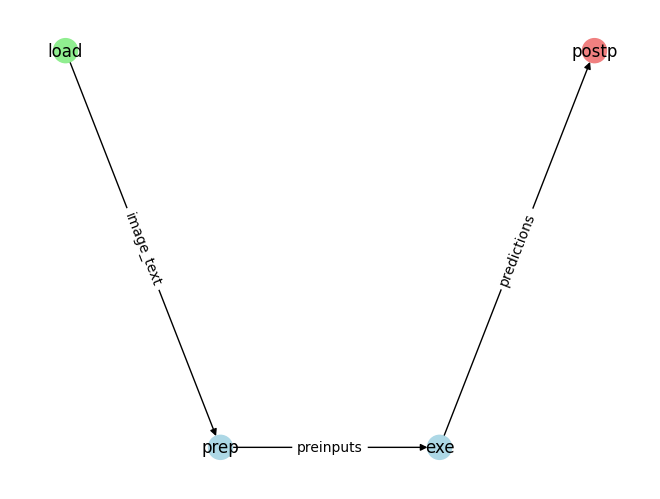

In [4]:
flow = db.GetFlow(flow_name, Creator=Flow)
flow.render()

In [5]:
flow.INFO

{'load': {'inputs': ('paths',), 'outputs': ('image_text',)},
 'prep': {'inputs': ('image_text',), 'outputs': ('preinputs',)},
 'exe': {'inputs': ('preinputs',), 'outputs': ('predictions',)},
 'postp': {'inputs': ('predictions',), 'outputs': ('result',)}}

In [8]:
flow.NAME, flow.NODES, flow.ENTRY, flow.EXIT

('vqa', ['load', 'prep', 'exe', 'postp'], 'load', 'postp')

In [9]:
for n in flow.nodes: print(n, flow.nodes[n])

load {'inputs': ('paths',), 'outputs': ('image_text',), 'subset': 0}
prep {'inputs': ('image_text',), 'outputs': ('preinputs',), 'subset': 1}
exe {'inputs': ('preinputs',), 'outputs': ('predictions',), 'subset': 2}
postp {'inputs': ('predictions',), 'outputs': ('result',), 'subset': 3}


In [10]:
for e in flow.edges: print(e, flow.edges[e])

('load', 'prep') {'data': 'image_text'}
('prep', 'exe') {'data': 'preinputs'}
('exe', 'postp') {'data': 'predictions'}
